# Stellar Mergers: Metallicity Sweep

In [1]:
import itertools
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import h5py
import pandas as pd
import yaml
from IPython.display import display

import time

In [2]:
pd.set_option('display.max_columns', None)

## Helper functions

In [3]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def save_yaml(obj, path):
    with open(path, "w") as f:
        yaml.safe_dump(obj, f, sort_keys=False)

def set_compas_option(cfg, key, value):
    """Insert a key/value into the correct yaml block based on Python type."""
    if isinstance(value, bool):
        cfg.setdefault("booleanChoices", {})[key] = value
    elif isinstance(value, (int, float)):
        cfg.setdefault("numericalChoices", {})[key] = value
    elif isinstance(value, str):
        cfg.setdefault("stringChoices", {})[key] = value
    else:
        raise TypeError(f"unsupported value type for {key}: {type(value)}")

def load_compas_group(h5_path, group_name):
    """Load a COMPAS HDF5 output group into a pandas DataFrame."""
    with h5py.File(h5_path, 'r') as f:
        if group_name not in f:
            return pd.DataFrame()
        group = f[group_name]
        data = {col: group[col][:] for col in group.keys()}
    return pd.DataFrame(data)

In [4]:
BASE_CONFIG = Path("../compas_config.yaml")

# Z and alpha_CE values to sweep
METALLICITIES = [0.02, 0.002, 0.0002]
ALPHA_VALUES  = [0.5, 1.0, 2.0]          
N_VALUES      = [1_000]  # Holding off on 10,000 for now

In [5]:
def run_metallicity_case(metallicity, n_systems, seed, alpha_ce=1.0, base_config=BASE_CONFIG):
    run_name = f"met_{metallicity:.4f}__n_{n_systems}__alpha_{alpha_ce}"

    cfg = load_yaml(base_config)
    set_compas_option(cfg, "--random-seed",              int(seed))
    set_compas_option(cfg, "--number-of-systems",        int(n_systems))
    set_compas_option(cfg, "--metallicity",              float(metallicity))
    set_compas_option(cfg, "--common-envelope-alpha",    float(alpha_ce))
    set_compas_option(cfg, "--logfile-type",             "HDF5")

    cfg_path = Path(f"config_{run_name}.yaml")
    save_yaml(cfg, cfg_path)

    # keep track of existing COMPAS_Output dirs to know which ones are new
    # from running this simulation
    before = set(Path(".").glob("COMPAS_Output*"))
    proc = subprocess.run(
        ["compas_run_submit", str(cfg_path)],
        capture_output=True, text=True,
    )
    if proc.returncode != 0:
        print(f"  FAILED [{run_name}]:\n{proc.stderr}")
        return None

    cfg_path.unlink()

    # keep track of the new COMPAS_Output dirs that were created: these
    # are the ones whose information we care about
    after = set(Path(".").glob("COMPAS_Output*"))
    new_dirs = after - before
    if not new_dirs:
        print(f"  No new COMPAS_Output dir found for {run_name}")
        return None
    
    if len(new_dirs) > 1:
        print(f"   More than 1 new directory created by {run_name}")

    # find the most recent new directory created, in case there was
    # more than one (this is an edge case in practice)
    new_dir  = max(new_dirs, key=lambda p: p.stat().st_mtime)
    h5_files = list(new_dir.glob("**/*.h5"))
    if not h5_files:
        print(f"  No HDF5 found in {new_dir}")
        return None

    return h5_files[0], metallicity, n_systems

# Stellar type legend (COMPAS)
-  0  = MS (< 0.7 Msun)
-  1  = MS (>= 0.7 Msun)
-  2  = Hertzsprung Gap 
-  3  = First Giant Branch
-  4  = Core He Burning
-  5  = Early AGB
-  6  = TPAGB
-  7  = He MS
-  8  = He HG
-  9  = He GB
- 10  = He WD
- 11 = CO WD  
- 12 = ONe WD  
- 13 = NS  
- 14 = BH  
- 15 = Massless remnant

Compact objects (CO) are types >= 10, so from this point on we EXCLUDE them to keep only stellar mergers.

In [6]:
STELLAR_TYPE_MAX = 9

In [7]:
def extract_case_counts(h5_path, n_systems):
    """
    Return per-MT-case merger counts (total + CE-only), filtering out any
    CE episode where either component is a compact object (type >= 10).

    Counts
    ------
    total_{a,b,c}  : all mergers in the non-CO CE sample
    ce_{a,b,c}     : subset that are flagged Merger==1 (i.e., they merged) inside BSE_Common_Envelopes
    n_total        : number of unique systems simulated
    """

    # BSE_System_Parameters is the one-row-per-binary summary table
    # It records the initial conditions and final outcome of every system COMPAS evolved
    sys_df = load_compas_group(str(h5_path), "BSE_System_Parameters")

    # BSE_Common_Envelopes records every common envelope event that occurred
    ce_df  = load_compas_group(str(h5_path), "BSE_Common_Envelopes")

    # number of unique systems actually evolved by COMPAS
    # if all runs correctly, this should be equal to the N value specified (1,000, 10,000, etc.)
    n_total = int(sys_df["SEED"].nunique()) if "SEED" in sys_df.columns else n_systems

    # prevent errors if there are no stellar mergers (edge case)
    zero = dict(n_total=n_total,
                total_a=0, total_b=0, total_c=0,
                ce_a=0,    ce_b=0,    ce_c=0)
    if ce_df.empty or "Merger" not in ce_df.columns:
        return zero

    ce = ce_df.copy()

    # count before filtering
    total_mergers_before = int((ce["Merger"] == 1).sum())

    # remove CE episodes involving a compact object (WD/NS/BH)
    stellar_ok = (
        (ce["Stellar_Type(1)<CE"] <= STELLAR_TYPE_MAX) &
        (ce["Stellar_Type(2)<CE"] <= STELLAR_TYPE_MAX)
    )
    ce = ce[stellar_ok]

    # count after filtering
    total_mergers_after = int((ce["Merger"] == 1).sum())

    print(f"  CE episodes (total):   {len(ce_df)}")
    print(f"  CE episodes (stellar): {len(ce)}")
    print(f"  CE mergers (total):    {total_mergers_before}")
    print(f"  CE mergers (stellar):  {total_mergers_after}")

    if ce.empty:
        return zero

    # identify the donor (the star filling its Roche lobe)
    donor_type = np.where(
        ce["RLOF(1)"] == 1,
        ce["Stellar_Type(1)<CE"],
        ce["Stellar_Type(2)<CE"],
    )

    # Classify mass transfer case (Case A, B, C)
    case_a_mask = (donor_type == 1)   # MS donor
    case_b_mask = (donor_type == 2)   # HG donor
    case_c_mask = (donor_type  > 2)   # Giant+ donor

    # All non-CO CE episodes (regardless of Merger flag)
    # CE mergers only
    merger_mask = ce["Merger"] == 1

    return dict(
        n_total = n_total, 
        
        # total CE events per case (stellar only)
        total_a = int(case_a_mask.sum()),
        total_b = int(case_b_mask.sum()),
        total_c = int(case_c_mask.sum()),
        
        # CE events that ended in a merger
        ce_a = int((case_a_mask & merger_mask).sum()),
        ce_b = int((case_b_mask & merger_mask).sum()),
        ce_c = int((case_c_mask & merger_mask).sum()),
    )

In [8]:
rows = []
seed = 200

In [9]:
# run the full grid: Z × N × alpha_CE
for alpha_ce, metallicity, n in itertools.product(ALPHA_VALUES, METALLICITIES, N_VALUES):
    start = time.time()
    run_label = f"Z={metallicity}  N={n:,}  alpha={alpha_ce}"

    print(f"Running  {run_label}  (seed={seed})", flush=True)
    result = run_metallicity_case(metallicity, n, seed=seed, alpha_ce=alpha_ce)
    seed  += 1

    if result is None:
        continue

    h5_path, met, n_sys = result
    counts = extract_case_counts(h5_path, n_sys)
    n_tot  = counts["n_total"]

    total_ce_events = counts["total_a"] + counts["total_b"] + counts["total_c"]
    ce_mergers    = counts["ce_a"]    + counts["ce_b"]    + counts["ce_c"]

    rows.append(dict(
        alpha_ce      = alpha_ce,
        metallicity   = met,
        n_systems     = n_tot,

        # raw merger counts
        total_a       = counts["total_a"],
        total_b       = counts["total_b"],
        total_c       = counts["total_c"],
        ce_a          = counts["ce_a"],
        ce_b          = counts["ce_b"],
        ce_c          = counts["ce_c"],
        total_ce_events = total_ce_events,
        ce_mergers    = ce_mergers,
        
        # rates (per system)
        rate_total_a  = counts["total_a"] / n_tot,
        rate_total_b  = counts["total_b"] / n_tot,
        rate_total_c  = counts["total_c"] / n_tot,
        rate_ce_a     = counts["ce_a"]    / n_tot,
        rate_ce_b     = counts["ce_b"]    / n_tot,
        rate_ce_c     = counts["ce_c"]    / n_tot,
    ))
    elapsed = time.time() - start

results_df = pd.DataFrame(rows)
display(results_df)

Running  Z=0.02  N=1,000  alpha=0.5  (seed=200)
  CE episodes (total):   464
  CE episodes (stellar): 346
  CE mergers (total):    339
  CE mergers (stellar):  298
Running  Z=0.002  N=1,000  alpha=0.5  (seed=201)
  CE episodes (total):   477
  CE episodes (stellar): 349
  CE mergers (total):    325
  CE mergers (stellar):  279
Running  Z=0.0002  N=1,000  alpha=0.5  (seed=202)
  CE episodes (total):   426
  CE episodes (stellar): 335
  CE mergers (total):    351
  CE mergers (stellar):  308
Running  Z=0.02  N=1,000  alpha=1.0  (seed=203)
  CE episodes (total):   480
  CE episodes (stellar): 347
  CE mergers (total):    310
  CE mergers (stellar):  268
Running  Z=0.002  N=1,000  alpha=1.0  (seed=204)
  CE episodes (total):   486
  CE episodes (stellar): 351
  CE mergers (total):    313
  CE mergers (stellar):  267
Running  Z=0.0002  N=1,000  alpha=1.0  (seed=205)
  CE episodes (total):   430
  CE episodes (stellar): 334
  CE mergers (total):    328
  CE mergers (stellar):  289
Running  Z

,alpha_ce,metallicity,n_systems,total_a,total_b,total_c,ce_a,ce_b,ce_c,total_ce_events,ce_mergers,rate_total_a,rate_total_b,rate_total_c,rate_ce_a,rate_ce_b,rate_ce_c
0,0.5,0.0200,1000,106,61,179,106,61,131,346,298,0.106,0.061,0.179,0.106,0.061,0.131
1,0.5,0.0020,1000,103,68,178,103,68,108,349,279,0.103,0.068,0.178,0.103,0.068,0.108
2,0.5,0.0002,1000,89,60,186,89,60,159,335,308,0.089,0.060,0.186,0.089,0.060,0.159
3,1.0,0.0200,1000,107,61,179,107,61,100,347,268,0.107,0.061,0.179,0.107,0.061,0.100
4,1.0,0.0020,1000,103,69,179,103,69,95,351,267,0.103,0.069,0.179,0.103,0.069,0.095
5,1.0,0.0002,1000,88,60,186,88,60,141,334,289,0.088,0.060,0.186,0.088,0.060,0.141
6,2.0,0.0200,1000,108,66,179,108,66,60,353,234,0.108,0.066,0.179,0.108,0.066,0.060
7,2.0,0.0020,1000,101,70,178,101,70,71,349,242,0.101,0.070,0.178,0.101,0.070,0.071
8,2.0,0.0002,1000,89,60,185,89,60,105,334,254,0.089,0.060,0.185,0.089,0.060,0.105


## Plots: Total mergers & CE rate vs metallicity

For each combination of N and alpha_CE, we produce two bar charts:

1. **Total mergers vs metallicity** — bars = Cases A/B/C; hatch overlay shows the CE-merger sub-fraction.
2. **CE mergers / N vs metallicity** — bars = Cases A/B/C; hatch overlay shows CE-only mergers.

In [10]:
CASE_COLORS = {
    "Case A (MS)":     "#2196F3",
    "Case B (HG)":     "#FF9800",
    "Case C (Giant+)": "#E53935",
}
CASE_KEYS  = ["A", "B", "C"]
CASE_LABELS = list(CASE_COLORS.keys())
HATCH      = "////"   # diagonal lines drawn on top of CE sub-fraction bars
ALPHA_FILL = 0.85
WIDTH      = 0.22      # width of each individual bar
ZLABELS    = [f"Z = {z}" for z in METALLICITIES]  # # → ["Z = 0.02", "Z = 0.002", "Z = 0.0002"]

x          = np.arange(len(METALLICITIES))   # [0, 1, 2] — tick positions for the 3 Z values

In [11]:
# takes a subplot ax and draws two layers of bars for each case (A, B, C):
def _add_case_bars(ax, sub, col_base, col_ce, colors, width=WIDTH, hatch=HATCH):
    """
    Draw grouped bars (col_base height) with a hatched overlay (col_ce height)
    for one subplot.  Returns bar containers for the legend.
    """
    bars, overlays = [], []
    for j, (label, color) in enumerate(colors.items()):

        # offsets the three bars sideways so they sit next to each other at each Z tick rather than overlapping
        # Case A is shifted left, Case B is centered, Case C is shifted right.
        offset  = (j - 1) * width
        heights = sub[col_base[j]].fillna(0).values
        ce_h    = sub[col_ce[j]].fillna(0).values

        # this draws the bars
        b = ax.bar(x + offset, heights, width=width,
                   color=color, edgecolor="white", linewidth=0.5,
                   alpha=ALPHA_FILL, label=label)
        
        # this draws the cross-hatched CE sub-bars over the bars
        o = ax.bar(x + offset, ce_h, width=width,
                   color=color, edgecolor="white", linewidth=0.5,
                   alpha=1.0, hatch=hatch)
        bars.append(b)
        overlays.append(o)
    return bars, overlays

Saved: mergers_n1000_alpha0.5.png


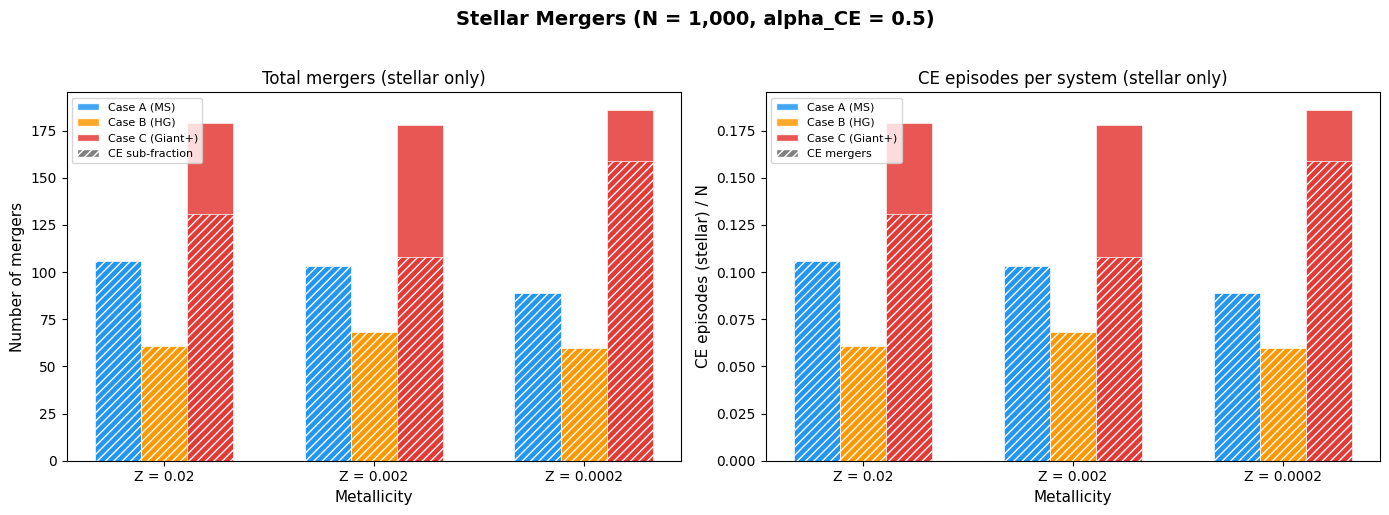

Saved: mergers_n1000_alpha1.0.png


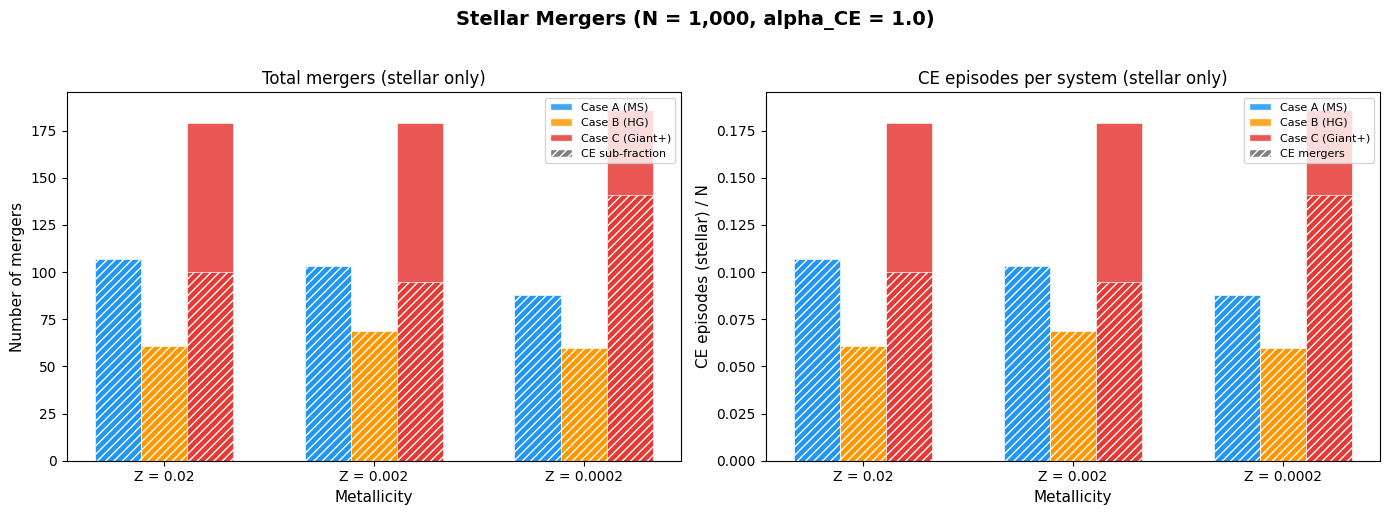

Saved: mergers_n1000_alpha2.0.png


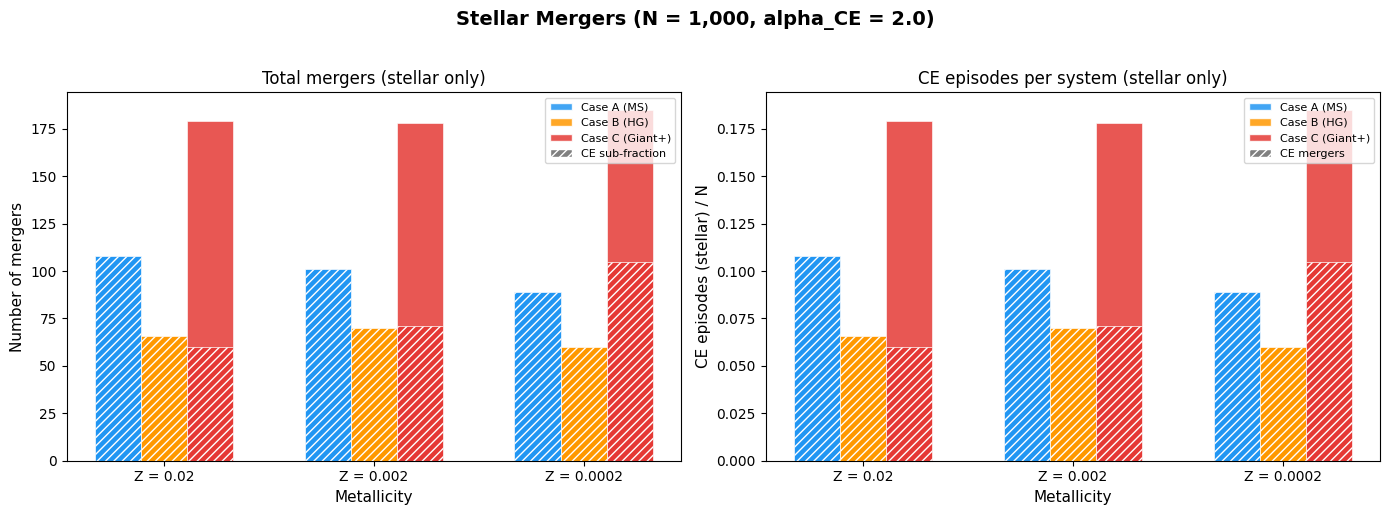

In [12]:
for alpha_ce in ALPHA_VALUES:
    for n in N_VALUES:

        sub = (
            results_df[
                (results_df["n_systems"]  == n) &
                (results_df["alpha_ce"]   == alpha_ce)
            ]
            .set_index("metallicity")
            .reindex(METALLICITIES)
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f"Stellar Mergers (N = {n:,}, alpha_CE = {alpha_ce})",
            fontsize=14, fontweight="bold", y=1.02
        )

        # PLOT 1: Total mergers (count) with CE hatch overlay
        ax = axes[0]
        _add_case_bars(
            ax, sub,
            col_base = ["total_a", "total_b", "total_c"],
            col_ce   = ["ce_a",    "ce_b",    "ce_c"],
            colors   = CASE_COLORS,
        )
        ax.set_xticks(x);  ax.set_xticklabels(ZLABELS, fontsize=10)
        ax.set_xlabel("Metallicity", fontsize=11)
        ax.set_ylabel("Number of mergers", fontsize=11)
        ax.set_title("Total mergers (stellar only)", fontsize=12)

        # Legend: case colours + CE hatch indicator
        legend_handles = [
            Patch(facecolor=c, edgecolor="white", label=l, alpha=ALPHA_FILL)
            for l, c in CASE_COLORS.items()
        ] + [
            Patch(facecolor="grey", hatch=HATCH, edgecolor="white", label="CE sub-fraction")
        ]
        ax.legend(handles=legend_handles, fontsize=8)

        # PLOT 2: CE mergers / N (rate)
        ax = axes[1]
        _add_case_bars(
            ax, sub,
            col_base = ["rate_total_a", "rate_total_b", "rate_total_c"],  # full bar = all CE episodes
            col_ce   = ["rate_ce_a",    "rate_ce_b",    "rate_ce_c"],     # hatch = CE mergers subset
            colors   = CASE_COLORS,
        )
        ax.set_xticks(x);  ax.set_xticklabels(ZLABELS, fontsize=10)
        ax.set_xlabel("Metallicity", fontsize=11)
        ax.set_ylabel("CE episodes (stellar) / N", fontsize=11)
        ax.set_title("CE episodes per system (stellar only)", fontsize=12)

        legend_handles2 = [
            Patch(facecolor=c, edgecolor="white", label=l, alpha=ALPHA_FILL)
            for l, c in CASE_COLORS.items()
        ] + [
            Patch(facecolor="grey", hatch=HATCH, edgecolor="white", label="CE mergers")
        ]
        ax.legend(handles=legend_handles2, fontsize=8)
        ax.legend(handles=legend_handles2, fontsize=8)

        plt.tight_layout()
        fname = f"mergers_n{n}_alpha{alpha_ce}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
        plt.show()